Loading + Cleaning Dataset

In [ ]:
import yfinance as yf
import pandas as pd

# 10 stocks for analysis
stocks = [
    "AAPL",   # Apple
    "MSFT",   # Microsoft
    "GOOGL",  # Google
    "AMZN",   # Amazon
    "TSLA",   # Tesla
    "META",   # Facebook
    "NVDA",   # Nvidia
    "JPM",    # JPMorgan
    "NFLX",   # Netflix
    "DIS"     # Disney
]

# Downloading the real data
data = yf.download(stocks, start="2020-01-01", end="2026-01-01")

# Converting  to clean format
data = data.stack(level=1).reset_index()

# Renaming columns
data.columns = ["Date", "Stock", "Open", "High", "Low", "Close", "Volume"]

# Saving the dataset
data.to_csv("10_stocks_dataset.csv", index=False)

print("Dataset is ready")

/tmp/ipykernel_9873/1589395528.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start="2020-01-01", end="2026-01-01")
[*********************100%***********************]  10 of 10 completed
/tmp/ipykernel_9873/1589395528.py:22: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  data = data.stack(level=1).reset_index()


Dataset is ready


In [ ]:

df = data # Assigning the 'data' DataFrame to 'df'
print(df.head())
print(df.info())

# converting date column properly
df["Date"] = pd.to_datetime(df["Date"])

# checking missing values
print(df.isnull().sum())

# droping missing values
df = df.dropna()

# removing duplicates
df = df.drop_duplicates()

# sorting values
df = df.sort_values(by=["Stock", "Date"])

print("Data is ready for analysis ")

        Date  Stock        Open        High         Low       Close     Volume
0 2020-01-02   AAPL   72.400513   72.460776   71.156674   71.409778  135480400
1 2020-01-02   AMZN   94.900497   94.900497   93.207497   93.750000   80580000
2 2020-01-02    DIS  144.790268  144.790268  141.761601  141.947217    9502100
3 2020-01-02  GOOGL   67.873016   67.873016   66.772614   66.867828   27278000
4 2020-01-02    JPM  118.430328  118.438731  116.894233  117.339111   10803700
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15080 entries, 0 to 15079
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    15080 non-null  datetime64[ns]
 1   Stock   15080 non-null  object        
 2   Open    15080 non-null  float64       
 3   High    15080 non-null  float64       
 4   Low     15080 non-null  float64       
 5   Close   15080 non-null  float64       
 6   Volume  15080 non-null  int64         
dtypes: datetime64[ns]

Import Visualization Libraries

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# For better visuals
sns.set_style("whitegrid")

EDA

1] LINE GRAPH

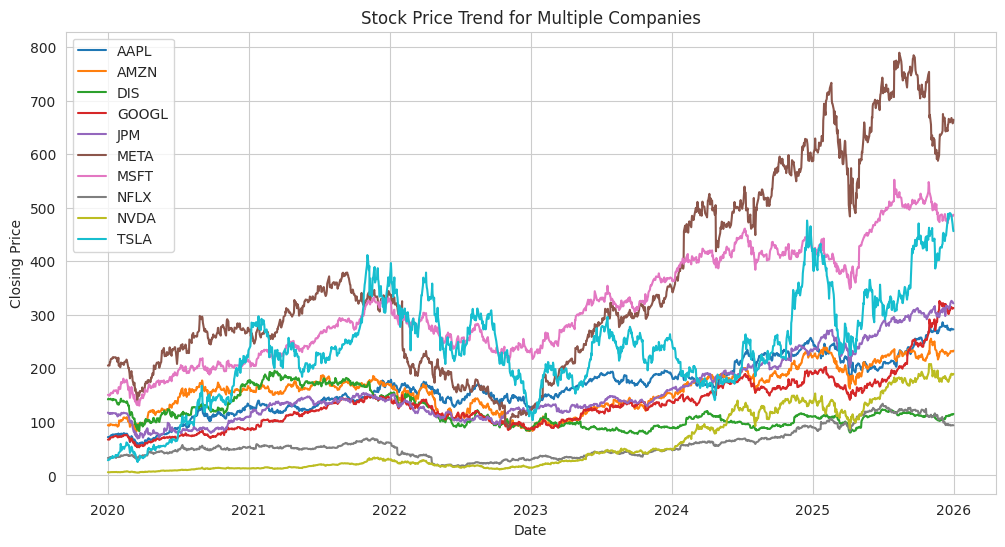

In [ ]:
plt.figure(figsize=(12,6))

# Using unique stock names from dataset
stocks = df["Stock"].unique()

for stock in stocks:
    temp = df[df["Stock"] == stock]
    plt.plot(temp["Date"], temp["Close"], label=stock)

plt.title("Stock Price Trend for Multiple Companies")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

BAR Graph

In [ ]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# geting all stocks
stocks = df["Stock"].unique()

# creating checkboxes
checkboxes = [widgets.Checkbox(value=False, description=stock) for stock in stocks]

# Creating button
button = widgets.Button(description="Plot Graph")

# output area
output = widgets.Output()

# Assigning function to plot
def plot_graph(b):
    selected = [cb.description for cb in checkboxes if cb.value]

    with output:
        output.clear_output()   # ✅ clears previous graph

        if len(selected) == 0:
            print("Please select at least one stock")
            return

        plt.figure(figsize=(12,6))

        for stock in selected:
            temp = df[df["Stock"] == stock]
            plt.plot(temp["Date"], temp["Close"], label=stock)

        plt.title("Stock Price Comparison")
        plt.xlabel("Date")
        plt.ylabel("Closing Price")
        plt.legend()
        plt.show()

# link button
button.on_click(plot_graph)

# For displaying UI
ui = widgets.VBox(checkboxes + [button, output])
display(ui)

Extracting Year

In [ ]:
df["Year"] = df["Date"].dt.year

In [ ]:
yearly_data = df.groupby(["Year", "Stock"]).agg({
    "Open": "mean",
    "Close": "mean",
    "Volume": "mean"
}).reset_index()




In [ ]:
stock_name = "AAPL"

data = yearly_data[yearly_data["Stock"] == stock_name]


In [ ]:
ax1.plot(data["Year"], data["Open"], marker="o", linewidth=2.5,
         linestyle="--", color=colors["open"], label="Open")

ax1.plot(data["Year"], data["Close"], marker="o", linewidth=2.5,
         linestyle="-", color=colors["close"], label="Close")

NameError: name 'ax1' is not defined

In [ ]:
marker="o"

In [ ]:
ax1.plot(data["Year"], data["Open"], alpha=0.8)
ax1.plot(data["Year"], data["Close"], alpha=1.0)

In [ ]:
ax1.plot(data["Year"] - 0.1, data["Open"])
ax1.plot(data["Year"] + 0.1, data["Close"])

In [ ]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import numpy as np

# get stocks
stocks = df["Stock"].unique()

# assign colors
stock_colors = {
    "AAPL": "#1f77b4",
    "MSFT": "#ff7f0e",
    "GOOGL": "#2ca02c",
    "AMZN": "#d62728",
    "TSLA": "#9467bd",
    "META": "#8c564b",
    "NVDA": "#e377c2",
    "JPM": "#7f7f7f",
    "NFLX": "#bcbd22",
    "DIS": "#17becf"
}

# checkboxes
stock_checkboxes = [widgets.Checkbox(value=False, description=s) for s in stocks]

open_cb = widgets.Checkbox(value=True, description="Show Open")
close_cb = widgets.Checkbox(value=True, description="Show Close")

button = widgets.Button(description="Update Graph")
output = widgets.Output()

def plot_graph(b):
    with output:
        output.clear_output()

        selected_stocks = [cb.description for cb in stock_checkboxes if cb.value]

        if len(selected_stocks) == 0:
            print("Please select at least one stock")
            return

        if not open_cb.value and not close_cb.value:
            print("Please select Open or Close")
            return

        # aggregate yearly data (cleaner for bar chart)
        df["Year"] = df["Date"].dt.year

        yearly = df.groupby(["Year", "Stock"]).agg({
            "Open": "mean",
            "Close": "mean"
        }).reset_index()

        fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

        # OPEN BAR CHART
        if open_cb.value:
            for i, stock in enumerate(selected_stocks):
                temp = yearly[yearly["Stock"] == stock]
                axes[0].bar(temp["Year"] + i*0.2,
                            temp["Open"],
                            width=0.2,
                            color=stock_colors.get(stock, "black"),
                            label=stock)

            axes[0].set_title("Opening Prices (Yearly Avg)")
            axes[0].set_xlabel("Year")
            axes[0].set_ylabel("Price")
            axes[0].legend(fontsize=7)
            axes[0].grid(alpha=0.3)

        else:
            axes[0].set_visible(False)

        # CLOSE BAR CHART
        if close_cb.value:
            for i, stock in enumerate(selected_stocks):
                temp = yearly[yearly["Stock"] == stock]
                axes[1].bar(temp["Year"] + i*0.2,
                            temp["Close"],
                            width=0.2,
                            color=stock_colors.get(stock, "red"),
                            label=stock)

            axes[1].set_title("Closing Prices (Yearly Avg)")
            axes[1].set_xlabel("Year")
            axes[1].legend(fontsize=7)
            axes[1].grid(alpha=0.3)

        else:
            axes[1].set_visible(False)

        plt.tight_layout()
        plt.show()

# button action
button.on_click(plot_graph)

# UI
stock_ui = widgets.VBox([
    widgets.HTML("<b>Select Stocks:</b>"),
    widgets.HBox(stock_checkboxes[:5]),
    widgets.HBox(stock_checkboxes[5:])
])

ui = widgets.VBox([
    stock_ui,
    widgets.HTML("<b>Select Data:</b>"),
    widgets.HBox([open_cb, close_cb]),
    button,
    output
])

display(ui)


DEFINE YOUR 10 STOCKS

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("dark_background")

colors = [
    "#00FFFF", "#FF00FF", "#FFD700", "#00FF7F",
    "#FF4500", "#1E90FF", "#FF1493", "#7CFC00",
    "#FFA500", "#00CED1"
]

In [ ]:
stocks = [
    "AAPL",   # Apple
    "MSFT",   # Microsoft
    "GOOGL",  # Google
    "AMZN",   # Amazon
    "TSLA",   # Tesla
    "META",   # Meta
    "NVDA",   # Nvidia
    "JPM",    # JPMorgan
    "NFLX",   # Netflix
    "DIS"     # Disney
]

CREATE GLOBAL CHECKBOXES (USE ONCE)

In [ ]:
import ipywidgets as widgets
from IPython.display import display

# create checkboxes
checkboxes = [widgets.Checkbox(value=False, description=s) for s in stocks]

# function to get selected stocks
def get_selected_stocks():
    return [cb.description for cb in checkboxes if cb.value]

# display UI
stock_selector = widgets.VBox([
    widgets.HTML("<b>Select Stocks for Analysis:</b>"),
    widgets.HBox(checkboxes[:5]),
    widgets.HBox(checkboxes[5:])
])

display(stock_selector)

USE SAME SELECTION IN ALL GRAPHS

In [ ]:
selected = get_selected_stocks()

In [ ]:
button = widgets.Button(description="Compare Stocks")
output = widgets.Output()

def plot_comparison(b):
    with output:
        output.clear_output()

        selected = get_selected_stocks()

        if len(selected) < 2:
            print("Select at least 2 stocks")
            return

        plt.figure(figsize=(12,5))

        for i, stock in enumerate(selected):
            temp = df[df["Stock"] == stock].copy()
            temp["Normalized"] = temp["Close"] / temp["Close"].iloc[0] * 100

            plt.plot(temp["Date"], temp["Normalized"],
                     label=stock)

        plt.legend()
        plt.title("Stock Comparison")
        plt.show()

button.on_click(plot_comparison)

display(button, output)

LINE GRAPH

In [ ]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

plt.style.use("dark_background")

colors = [
    "#00FFFF", "#FF00FF", "#FFD700", "#00FF7F",
    "#FF4500", "#1E90FF", "#FF1493", "#7CFC00",
    "#FFA500", "#00CED1"
]

stocks = df["Stock"].unique()

# checkboxes (better UX)
checkboxes = [widgets.Checkbox(value=False, description=s) for s in stocks]

button = widgets.Button(description="Compare Stocks")
output = widgets.Output()

def plot_comparison(b):
    with output:
        output.clear_output()

        selected = [cb.description for cb in checkboxes if cb.value]

        if len(selected) < 2:
            print("Select at least 2 stocks for comparison")
            return

        plt.figure(figsize=(12,5))

        for i, stock in enumerate(selected):
            temp = df[df["Stock"] == stock].copy()

            # normalize (BASE = 100)
            temp["Normalized"] = temp["Close"] / temp["Close"].iloc[0] * 100

            plt.plot(temp["Date"], temp["Normalized"],
                     color=colors[i],
                     linewidth=2,
                     label=stock)

        plt.title("Stock Performance Comparison (Base = 100)")
        plt.xlabel("Date")
        plt.ylabel("Growth Index")
        plt.legend()
        plt.grid(alpha=0.2)
        plt.show()

button.on_click(plot_comparison)

ui = widgets.VBox([
    widgets.HTML("<b>Select Stocks for Comparison:</b>"),
    widgets.HBox(checkboxes[:5]),
    widgets.HBox(checkboxes[5:]),
    button,
    output
])

display(ui)

Bar Graph

In [ ]:
output2 = widgets.Output()

def total_return(b):
    with output2:
        output2.clear_output()

        selected = [cb.description for cb in checkboxes if cb.value]

        if len(selected) < 2:
            print("Select at least 2 stocks")
            return

        returns = {}

        for stock in selected:
            temp = df[df["Stock"] == stock]
            ret = ((temp["Close"].iloc[-1] - temp["Close"].iloc[0])
                   / temp["Close"].iloc[0]) * 100
            returns[stock] = ret

        plt.figure(figsize=(8,5))
        plt.bar(returns.keys(), returns.values(), color=colors)

        plt.title("Total Return Comparison (%)")
        plt.ylabel("Return %")
        plt.show()

btn2 = widgets.Button(description="Compare Returns")
btn2.on_click(total_return)

display(btn2, output2)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

# dark theme
plt.style.use("dark_background")

# vibrant colors
colors = [
    "#00FFFF", "#FF00FF", "#FFD700", "#00FF7F",
    "#FF4500", "#1E90FF", "#FF1493", "#7CFC00",
    "#FFA500", "#00CED1"
]

# stock list
stocks = [
    "AAPL","MSFT","GOOGL","AMZN","TSLA",
    "META","NVDA","JPM","NFLX","DIS"
]

# checkboxes
checkboxes = [widgets.Checkbox(value=False, description=s) for s in stocks]

def get_selected():
    return [cb.description for cb in checkboxes if cb.value]

# UI
display(widgets.VBox([
    widgets.HTML("<b>Select Stocks:</b>"),
    widgets.HBox(checkboxes[:5]),
    widgets.HBox(checkboxes[5:])
]))

In [ ]:
btn1 = widgets.Button(description="Line Comparison")
out1 = widgets.Output()

def line_graph(b):
    with out1:
        out1.clear_output()

        selected = get_selected()
        if len(selected) < 2:
            print("Select at least 2 stocks")
            return

        plt.figure(figsize=(12,5))

        for i, stock in enumerate(selected):
            temp = df[df["Stock"] == stock].copy()
            temp["Norm"] = temp["Close"] / temp["Close"].iloc[0] * 100

            plt.plot(temp["Date"], temp["Norm"],
                     color=colors[i], label=stock)

        plt.title("Normalized Stock Comparison")
        plt.legend()
        plt.show()

btn1.on_click(line_graph)
display(btn1, out1)

In [ ]:
btn3 = widgets.Button(description="Returns")
out3 = widgets.Output()

def show_ret(b):
    out3.clear_output()

    sel = [x.description for x in checkboxes if x.value] # Corrected 'cbs' to 'checkboxes'

    with out3:
        r = {}
        for s in sel:
            t = df[df["Stock"]==s]
            r[s] = (t["Close"].iloc[-1]-t["Close"].iloc[0])/t["Close"].iloc[0]*100

        plt.bar(r.keys(), r.values(), color=colors) # Corrected 'cols' to 'colors'
        plt.title("returns %")
        plt.show()

btn3.on_click(show_ret)
display(btn3,out3)

In [ ]:
btn4 = widgets.Button(description="Boxplot")
out4 = widgets.Output()

def show_box(b):
    out4.clear_output()

    sel = [x.description for x in checkboxes if x.value]

    with out4:
        data = df[df["Stock"].isin(sel)]

        sns.boxplot(x="Stock", y="Close", data=data)
        plt.xticks(rotation=45)
        plt.show()

btn4.on_click(show_box)
display(btn4,out4)

In [ ]:
btn5 = widgets.Button(description="Heatmap")
out5 = widgets.Output()

def show_heat(b):
    out5.clear_output()

    with out5:
        corr = df[["Open","High","Low","Close","Volume"]].corr()

        sns.heatmap(corr, annot=True)
        plt.show()

btn5.on_click(show_heat)
display(btn5,out5)

In [ ]:
btn6 = widgets.Button(description="Scatter")
out6 = widgets.Output()

def show_scatter(b):
    out6.clear_output()

    with out6:
        plt.scatter(df["Volume"], df["Close"], alpha=0.4)
        plt.title("vol vs price")
        plt.show()

btn6.on_click(show_scatter)
display(btn6,out6)

In [ ]:
btn7 = widgets.Button(description="Pie")
out7 = widgets.Output()

def show_pie(b):
    out7.clear_output()

    sel = [x.description for x in checkboxes if x.value]

    with out7:
        data = df[df["Stock"].isin(sel)]
        v = data.groupby("Stock")["Volume"].sum()

        plt.pie(v, labels=v.index, autopct="%1.1f%%")
        plt.show()

btn7.on_click(show_pie)
display(btn7,out7)